# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

print('Library berhasil diimport!')

Library berhasil diimport!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
# Load dataset raw
df = pd.read_csv('/content/dataset.csv')
print(f'Dataset berhasil dimuat!')
print(f'Shape: {df.shape}')
print(f'Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}')

Dataset berhasil dimuat!
Shape: (1007, 8)
Jumlah baris: 1007, Jumlah kolom: 8


In [3]:
# Tampilkan 5 baris pertama
df.head()

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,Porsche,911,2022,3,379,331,4,"101,200"
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390"
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750"
3,Audi,R8,2022,5.2,562,406,3.2,"142,700"
4,McLaren,720S,2021,4,710,568,2.7,"298,000"


In [4]:
# Tampilkan info kolom
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Car Make                 1007 non-null   object
 1   Car Model                1007 non-null   object
 2   Year                     1007 non-null   int64 
 3   Engine Size (L)          997 non-null    object
 4   Horsepower               1007 non-null   object
 5   Torque (lb-ft)           1004 non-null   object
 6   0-60 MPH Time (seconds)  1007 non-null   object
 7   Price (in USD)           1007 non-null   object
dtypes: int64(1), object(7)
memory usage: 63.1+ KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
# Konversi kolom numerik terlebih dahulu untuk keperluan describe
df_temp = df.copy()
numeric_cols = ['Engine Size (L)', 'Horsepower', 'Torque (lb-ft)', '0-60 MPH Time (seconds)']
for col in numeric_cols:
    df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')
df_temp['Price (in USD)'] = df_temp['Price (in USD)'].str.replace(',', '').astype(float)

df_temp.describe()

,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
count,1007.000000,948.000000,998.000000,999.000000,1006.000000,1.007000e+03
mean,2021.201589,4.395781,627.324649,542.185185,3.515010,3.820359e+05
std,2.019802,1.398801,299.973805,242.509345,0.776358,7.383227e+05
min,1965.000000,0.000000,181.000000,0.000000,1.800000,2.500000e+04
25%,2021.000000,3.500000,454.000000,406.000000,2.900000,7.180000e+04
50%,2021.000000,4.000000,591.000000,509.000000,3.500000,1.400000e+05
75%,2022.000000,5.200000,671.000000,604.000000,4.000000,2.500000e+05
max,2023.000000,8.400000,2000.000000,1732.000000,6.500000,5.200000e+06


Missing values (raw):
Car Make                    0
Car Model                   0
Year                        0
Engine Size (L)            10
Horsepower                  0
Torque (lb-ft)              3
0-60 MPH Time (seconds)     0
Price (in USD)              0
dtype: int64

Missing values (setelah konversi numerik):
Car Make                    0
Car Model                   0
Year                        0
Engine Size (L)            59
Horsepower                  9
Torque (lb-ft)              8
0-60 MPH Time (seconds)     1
Price (in USD)              0
dtype: int64


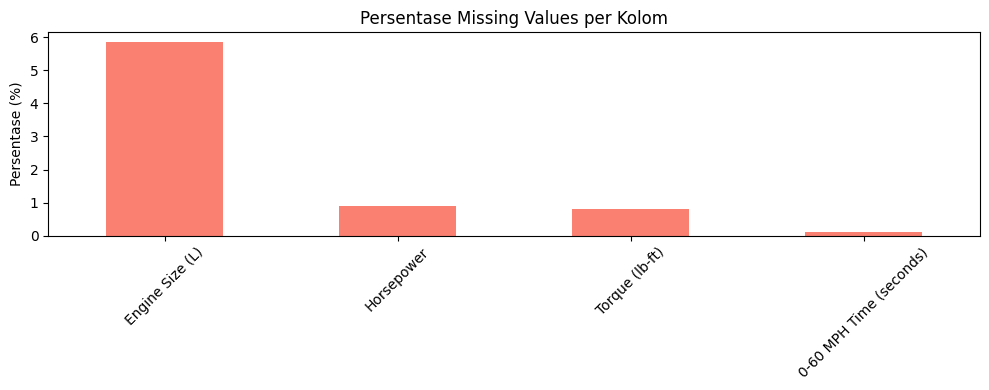

In [6]:
# Cek missing values sebelum konversi
print('Missing values (raw):')
print(df.isnull().sum())
print()

# Cek missing values setelah konversi
print('Missing values (setelah konversi numerik):')
print(df_temp.isnull().sum())

# Visualisasi missing values
plt.figure(figsize=(10, 4))
missing_pct = df_temp.isnull().sum() / len(df_temp) * 100
missing_pct[missing_pct > 0].plot(kind='bar', color='salmon')
plt.title('Persentase Missing Values per Kolom')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
print(f'Jumlah data duplikat: {df.duplicated().sum()}')
print(f'Persentase duplikat: {df.duplicated().sum()/len(df)*100:.2f}%')

Jumlah data duplikat: 288
Persentase duplikat: 28.60%


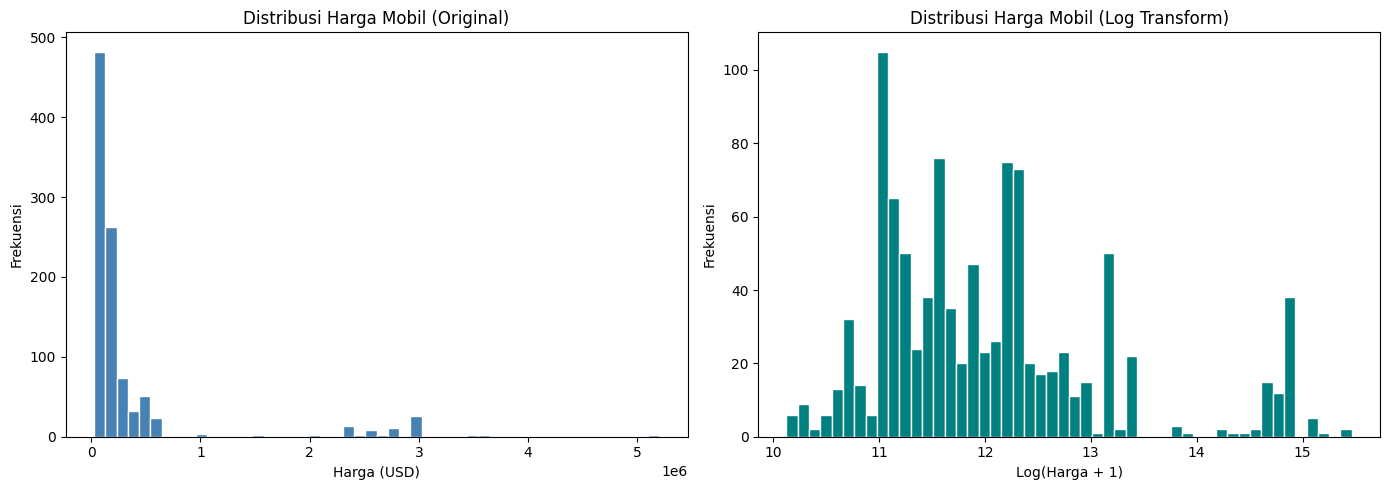

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi price sebelum log
axes[0].hist(df_temp['Price (in USD)'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Harga Mobil (Original)')
axes[0].set_xlabel('Harga (USD)')
axes[0].set_ylabel('Frekuensi')

# Distribusi price setelah log
axes[1].hist(np.log1p(df_temp['Price (in USD)'].dropna()), bins=50, color='teal', edgecolor='white')
axes[1].set_title('Distribusi Harga Mobil (Log Transform)')
axes[1].set_xlabel('Log(Harga + 1)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

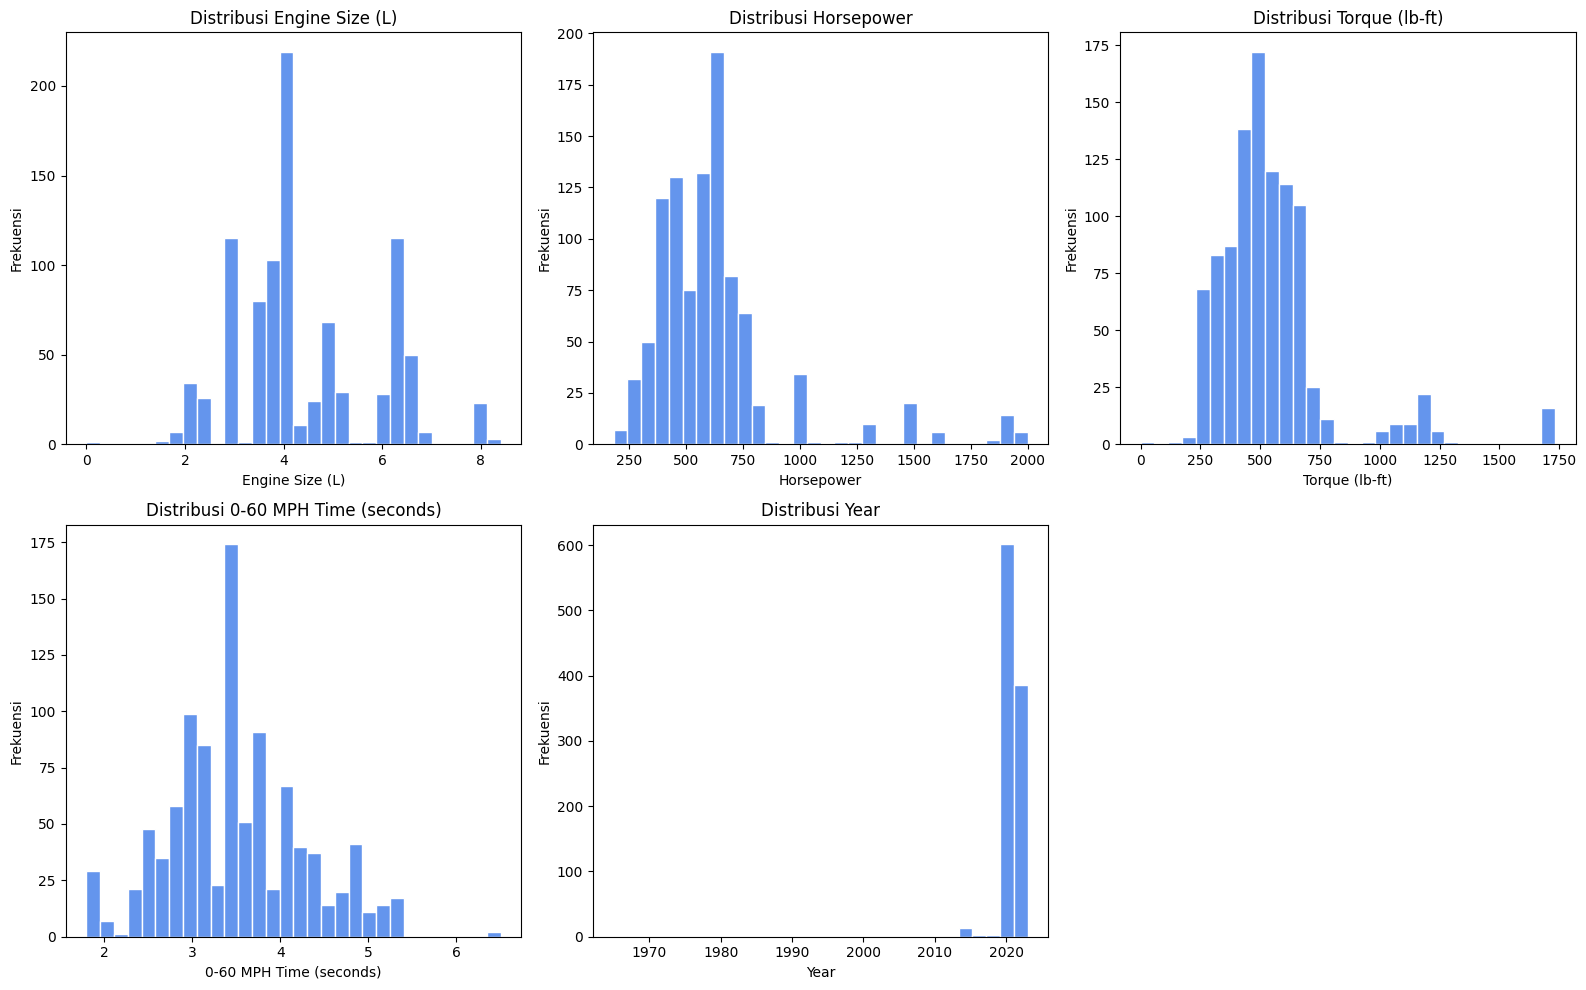

In [8]:
num_features = ['Engine Size (L)', 'Horsepower', 'Torque (lb-ft)', '0-60 MPH Time (seconds)', 'Year']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df_temp[col].dropna(), bins=30, color='cornflowerblue', edgecolor='white')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

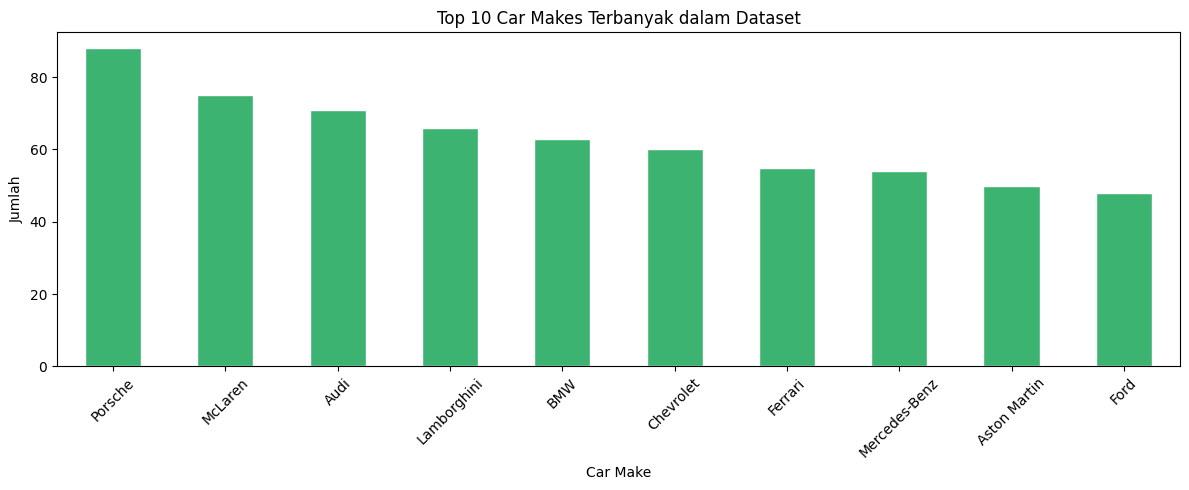

In [9]:
plt.figure(figsize=(12, 5))
top_makes = df['Car Make'].value_counts().head(10)
top_makes.plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Top 10 Car Makes Terbanyak dalam Dataset')
plt.xlabel('Car Make')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

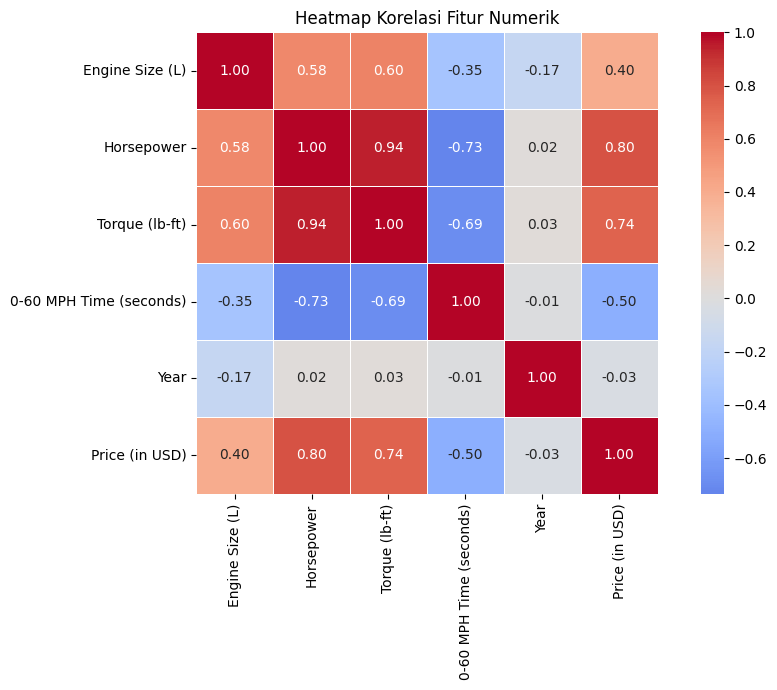

In [10]:
plt.figure(figsize=(10, 7))
corr_matrix = df_temp[num_features + ['Price (in USD)']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

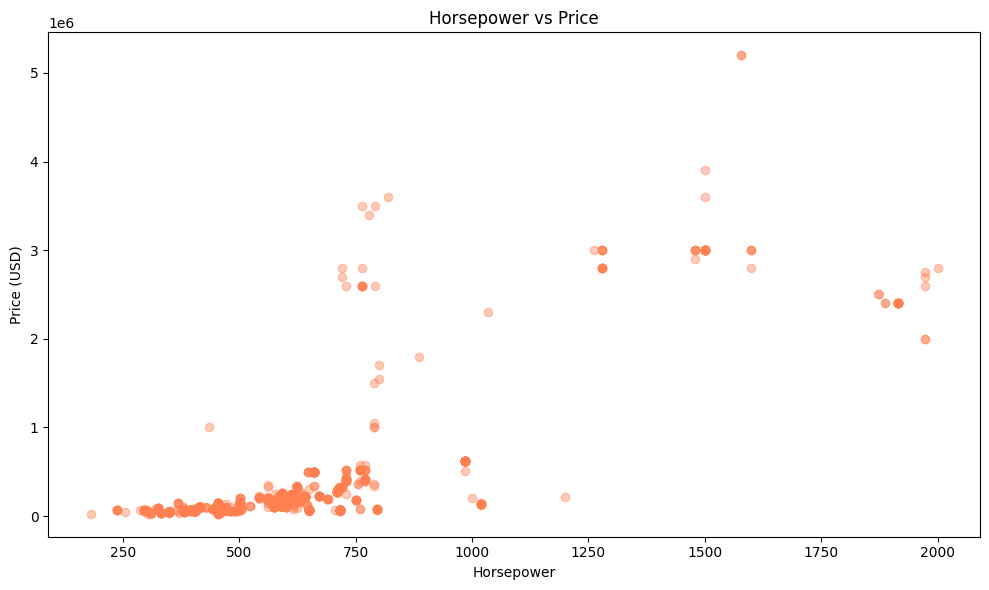

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(df_temp['Horsepower'], df_temp['Price (in USD)'], alpha=0.4, color='coral')
plt.title('Horsepower vs Price')
plt.xlabel('Horsepower')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

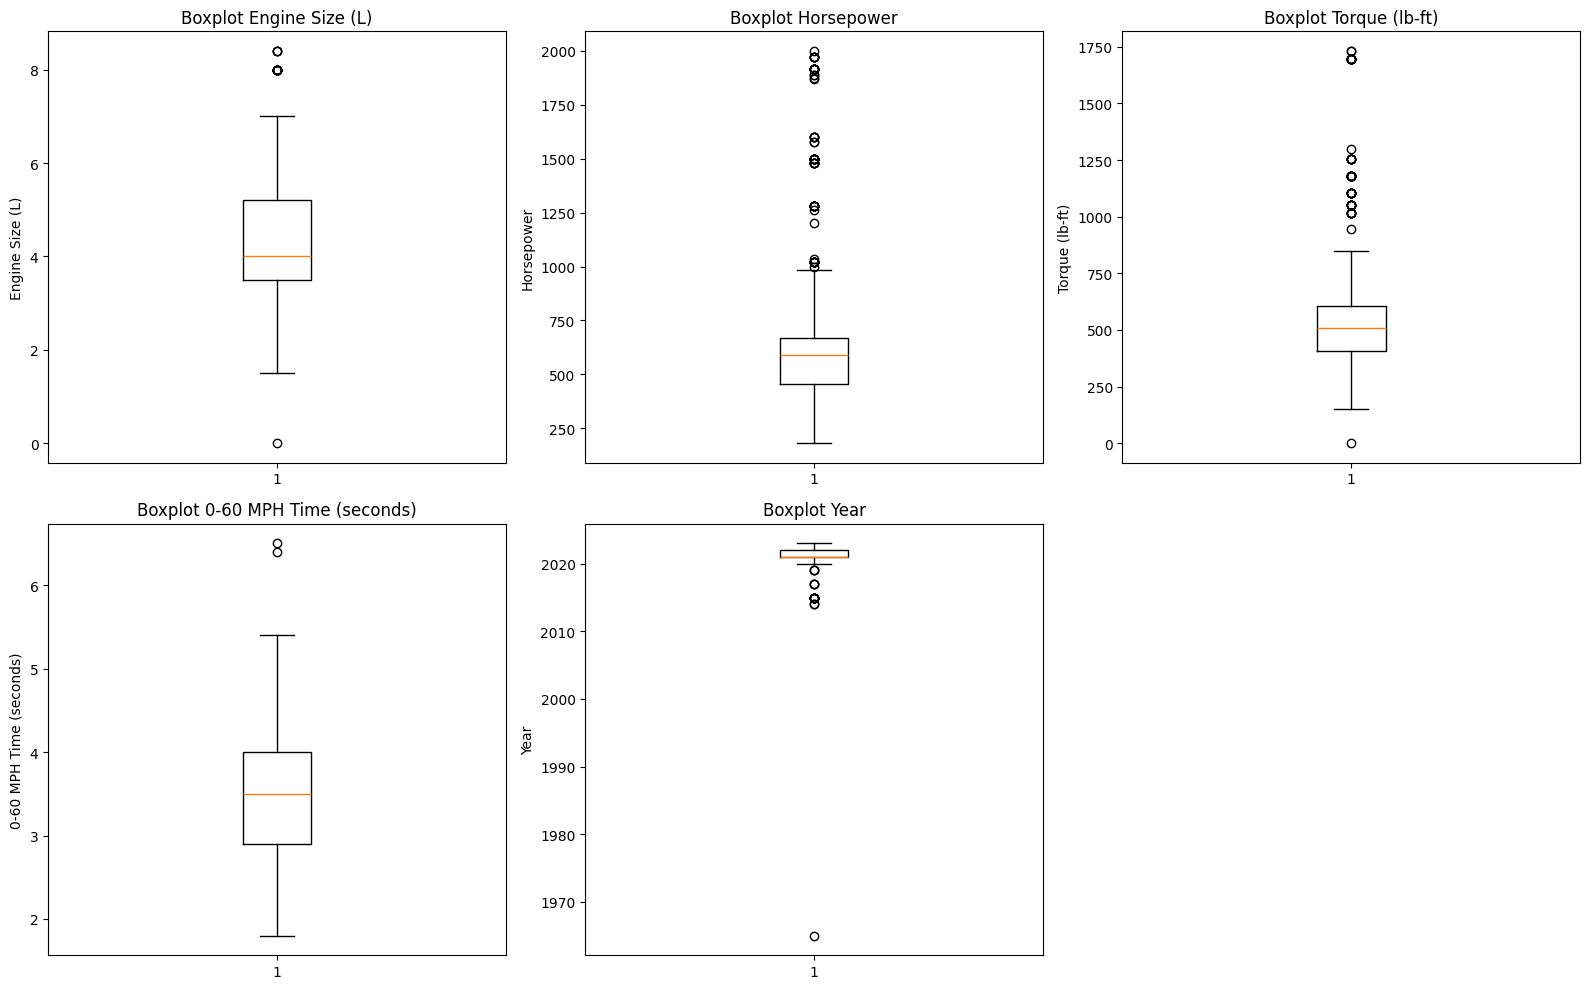

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].boxplot(df_temp[col].dropna())
    axes[i].set_title(f'Boxplot {col}')
    axes[i].set_ylabel(col)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
df_proc = df.copy()

# Konversi kolom numerik
numeric_cols = ['Engine Size (L)', 'Horsepower', 'Torque (lb-ft)', '0-60 MPH Time (seconds)']
for col in numeric_cols:
    df_proc[col] = pd.to_numeric(df_proc[col], errors='coerce')

# Konversi Price: hilangkan koma lalu jadikan float
df_proc['Price (in USD)'] = df_proc['Price (in USD)'].str.replace(',', '').astype(float)

print('Konversi tipe data selesai.')
print(df_proc.dtypes)

Konversi tipe data selesai.
Car Make                    object
Car Model                   object
Year                         int64
Engine Size (L)            float64
Horsepower                 float64
Torque (lb-ft)             float64
0-60 MPH Time (seconds)    float64
Price (in USD)             float64
dtype: object


In [14]:
sebelum = df_proc.shape[0]
df_proc = df_proc.drop_duplicates()
sesudah = df_proc.shape[0]
print(f'Baris sebelum drop duplikat : {sebelum}')
print(f'Baris setelah drop duplikat  : {sesudah}')
print(f'Jumlah duplikat yang dihapus : {sebelum - sesudah}')

Baris sebelum drop duplikat : 1007
Baris setelah drop duplikat  : 715
Jumlah duplikat yang dihapus : 292


In [15]:
print('Missing values sebelum penanganan:')
print(df_proc.isnull().sum())

# Isi missing value numerik dengan median
for col in numeric_cols:
    median_val = df_proc[col].median()
    df_proc[col] = df_proc[col].fillna(median_val)
    print(f'  [{col}] missing diisi dengan median: {median_val:.2f}')

print()
print('Missing values setelah penanganan:')
print(df_proc.isnull().sum())

Missing values sebelum penanganan:
Car Make                    0
Car Model                   0
Year                        0
Engine Size (L)            50
Horsepower                  7
Torque (lb-ft)              6
0-60 MPH Time (seconds)     1
Price (in USD)              0
dtype: int64
  [Engine Size (L)] missing diisi dengan median: 4.00
  [Horsepower] missing diisi dengan median: 587.00
  [Torque (lb-ft)] missing diisi dengan median: 505.00
  [0-60 MPH Time (seconds)] missing diisi dengan median: 3.50

Missing values setelah penanganan:
Car Make                   0
Car Model                  0
Year                       0
Engine Size (L)            0
Horsepower                 0
Torque (lb-ft)             0
0-60 MPH Time (seconds)    0
Price (in USD)             0
dtype: int64


In [16]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(data)
    data = data[(data[column] >= lower) & (data[column] <= upper)]
    after = len(data)
    print(f'  [{column}] dihapus {before-after} outlier (lower={lower:.2f}, upper={upper:.2f})')
    return data

print('Penanganan outlier dengan IQR:')
print(f'Baris sebelum: {len(df_proc)}')

outlier_cols = ['Horsepower', 'Torque (lb-ft)', 'Engine Size (L)', 'Price (in USD)']
for col in outlier_cols:
    df_proc = remove_outliers_iqr(df_proc, col)

print(f'Baris sesudah: {len(df_proc)}')

Penanganan outlier dengan IQR:
Baris sebelum: 715
  [Horsepower] dihapus 44 outlier (lower=100.00, upper=1044.00)
  [Torque (lb-ft)] dihapus 11 outlier (lower=75.00, upper=899.00)
  [Engine Size (L)] dihapus 5 outlier (lower=0.95, upper=7.75)
  [Price (in USD)] dihapus 48 outlier (lower=-154513.50, upper=441522.50)
Baris sesudah: 607


In [17]:
le_make = LabelEncoder()
le_model = LabelEncoder()

df_proc['Car Make Encoded'] = le_make.fit_transform(df_proc['Car Make'])
df_proc['Car Model Encoded'] = le_model.fit_transform(df_proc['Car Model'])

# Drop kolom kategorikal asli
df_proc = df_proc.drop(columns=['Car Make', 'Car Model'])

print('Encoding selesai.')
print(df_proc.head())

Encoding selesai.
   Year  Engine Size (L)  Horsepower  Torque (lb-ft)  0-60 MPH Time (seconds)  \
0  2022              3.0       379.0           331.0                      4.0   
1  2021              5.2       630.0           443.0                      2.8   
2  2022              3.9       661.0           561.0                      3.0   
3  2022              5.2       562.0           406.0                      3.2   
4  2021              4.0       710.0           568.0                      2.7   

   Price (in USD)  Car Make Encoded  Car Model Encoded  
0        101200.0                24                 18  
1        274390.0                14                 84  
2        333750.0                10                  5  
3        142700.0                 5                111  
4        298000.0                19                 15  


In [18]:
# Pisahkan fitur dan target
target = 'Price (in USD)'
feature_cols = [col for col in df_proc.columns if col != target]

X = df_proc[feature_cols]
y = df_proc[target]

# Scaling fitur
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

print('Scaling selesai.')
print('Shape fitur:', X_scaled.shape)
print('Shape target:', y.shape)
X_scaled.describe().round(3)

Scaling selesai.
Shape fitur: (607, 7)
Shape target: (607,)


,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Car Make Encoded,Car Model Encoded
count,607.000,607.000,607.000,607.000,607.000,607.000,607.000
mean,0.000,-0.000,-0.000,0.000,-0.000,0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-7.523,-2.143,-2.586,-2.504,-2.664,-1.791,-1.768
25%,-0.273,-0.576,-0.844,-0.706,-0.649,-0.869,-0.632
50%,-0.273,-0.185,-0.051,-0.058,-0.218,-0.210,-0.111
75%,0.763,0.677,0.702,0.883,0.502,0.977,0.789
max,1.798,2.009,3.634,2.303,3.954,2.031,1.760


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'X_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')
print(f'y_train shape : {y_train.shape}')
print(f'y_test shape  : {y_test.shape}')

X_train shape : (485, 7)
X_test shape  : (122, 7)
y_train shape : (485,)
y_test shape  : (122,)


In [20]:
import os
os.makedirs('dataset_preprocessing', exist_ok=True)

# Gabungkan kembali X_scaled dan y untuk disimpan
df_final = X_scaled.copy()
df_final[target] = y.reset_index(drop=True)

df_final.to_csv('dataset_preprocessing/dataset_preprocessing.csv', index=False)
print(f'Dataset preprocessing tersimpan!')
print(f'Shape final: {df_final.shape}')
df_final.head()

Dataset preprocessing tersimpan!
Shape final: (607, 8)


,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Car Make Encoded,Car Model Encoded,Price (in USD)
0,0.762732,-0.967941,-1.118378,-1.115032,0.357661,1.372183,-1.341886,101200.0
1,-0.273014,0.755280,0.742597,-0.250879,-1.368781,0.054071,0.220729,274390.0
2,0.762732,-0.262987,0.972439,0.659567,-1.081041,-0.473174,-1.649674,333750.0
3,0.762732,0.755280,0.238428,-0.536358,-0.793300,-1.132230,0.859980,142700.0
4,-0.273014,-0.184659,1.335737,0.713577,-1.512651,0.713127,-1.412914,298000.0
